In [1]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot
import imblearn
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn import datasets
from sklearn.preprocessing import LabelBinarizer

In [3]:
df = pd.read_excel("/content/perfect_final_data_for_multilevel_analysis.xlsx")
df

,V001,V002,V012,V013,V024,V025,V106,V113,V130,V157,...,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,469,57,48,7,6,2,0,21,1,0,...,2,2,2,1,4,2,0,1,4,1
1,438,26,32,4,6,1,2,21,1,0,...,1,1,1,2,1,2,2,1,4,0
2,296,96,39,5,4,1,2,21,1,0,...,2,2,2,4,1,2,2,1,4,1
3,438,4,48,7,6,1,0,21,1,0,...,2,2,2,2,1,2,2,1,4,0
4,548,158,32,4,7,2,3,12,1,0,...,1,1,1,1,2,1,0,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,417,132,41,6,5,2,1,21,1,0,...,2,1,2,1,3,2,0,1,1,0
8498,190,11,43,6,3,1,0,11,1,0,...,1,1,1,3,3,1,1,1,1,1
8499,123,123,40,6,2,2,0,21,1,0,...,1,1,2,2,1,2,0,1,1,1
8500,581,64,30,4,7,2,1,21,2,0,...,2,2,1,2,2,2,0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 41 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V001                        8502 non-null   int64  
 1   V002                        8502 non-null   int64  
 2   V012                        8502 non-null   int64  
 3   V013                        8502 non-null   int64  
 4   V024                        8502 non-null   int64  
 5   V025                        8502 non-null   int64  
 6   V106                        8502 non-null   int64  
 7   V113                        8502 non-null   int64  
 8   V130                        8502 non-null   int64  
 9   V157                        8502 non-null   int64  
 10  V158                        8502 non-null   int64  
 11  V159                        8502 non-null   int64  
 12  V190                        8502 non-null   int64  
 13  V201                        8502 

In [6]:
df.drop(columns=['V001', 'V002', 'V012', 'V113', 'V130', 'V157', 'V158',
                 'V159', 'V190', 'V201', 'V212', 'V218', 'V221', 'V364', 'V445','V447', 'V501',
                 'V502', 'V701', 'V705', 'V730'], inplace=True)

In [7]:
df.head(5)

,V013,V024,V025,V106,V404,V714,BMI_fixed,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,BMI,Respondent_Age_first_birth
0,7,6,2,0,0,0,46.90,0,0,0,2,2,2,1,4,2,0,1,4,1
1,4,6,1,2,0,1,46.74,1,2,0,1,1,1,2,1,2,2,1,4,0
2,5,4,1,2,0,0,45.28,1,3,1,2,2,2,4,1,2,2,1,4,1
3,7,6,1,0,0,0,45.21,1,2,0,2,2,2,2,1,2,2,1,4,0
4,4,7,2,3,0,0,45.09,0,1,0,1,1,1,1,2,1,0,1,4,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   V013                        8502 non-null   int64  
 1   V024                        8502 non-null   int64  
 2   V025                        8502 non-null   int64  
 3   V106                        8502 non-null   int64  
 4   V404                        8502 non-null   int64  
 5   V714                        8502 non-null   int64  
 6   BMI_fixed                   8502 non-null   float64
 7   Media_acccess               8502 non-null   int64  
 8   husband_education           8502 non-null   int64  
 9   contraceptive_use           8502 non-null   int64  
 10  Number_of_children          8502 non-null   int64  
 11  Living_children             8502 non-null   int64  
 12  Age_of_husband              8502 non-null   int64  
 13  profession_of_husband       8502 

In [10]:
df.drop(columns=['BMI_fixed'], inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [13]:
# Robust Scaling (FT4)
from sklearn.preprocessing import RobustScaler  # import robust scaler
FT4 = RobustScaler()  # create the robust scaler
FT4_data = FT4.fit_transform(df)  # scale data using median and spread
FT4_df = pd.DataFrame(FT4_data, columns=df.columns)  # convert scaled data into a DataFrame
print(FT4_df.head())  # show the first few robust scaled rows

       V013  V024  V025  V106  V404  V714  Media_acccess  husband_education  \
0  1.000000  0.50   0.0  -2.0   0.0   0.0           -1.0               -1.0   
1  0.000000  0.50  -1.0   0.0   0.0   1.0            0.0                1.0   
2  0.333333  0.00  -1.0   0.0   0.0   0.0            0.0                2.0   
3  1.000000  0.50  -1.0  -2.0   0.0   0.0            0.0                1.0   
4  0.000000  0.75   0.0   1.0   0.0   0.0           -1.0                0.0   

   contraceptive_use  Number_of_children  Living_children  Age_of_husband  \
0               -1.0                 1.0              1.0             1.0   
1               -1.0                 0.0              0.0             0.0   
2                0.0                 1.0              1.0             1.0   
3               -1.0                 1.0              1.0             1.0   
4               -1.0                 0.0              0.0             0.0   

   profession_of_husband  Birth_Interval  Drinking_water  Weal

In [14]:
df.info()  # check the data types and missing values again

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   V013                        8502 non-null   int64
 1   V024                        8502 non-null   int64
 2   V025                        8502 non-null   int64
 3   V106                        8502 non-null   int64
 4   V404                        8502 non-null   int64
 5   V714                        8502 non-null   int64
 6   Media_acccess               8502 non-null   int64
 7   husband_education           8502 non-null   int64
 8   contraceptive_use           8502 non-null   int64
 9   Number_of_children          8502 non-null   int64
 10  Living_children             8502 non-null   int64
 11  Age_of_husband              8502 non-null   int64
 12  profession_of_husband       8502 non-null   int64
 13  Birth_Interval              8502 non-null   int64
 14  Drinking

In [15]:
# FT4_df.head()  # this would preview the robust scaled data
y = FT4_df.BMI  # use bmi1 as the target variable
x = FT4_df.drop('BMI', axis=1)  # use the other columns as features

In [16]:
y  # display the target column

,BMI
0,2.0
1,2.0
2,2.0
3,2.0
4,2.0
...,...
8497,-1.0
8498,-1.0
8499,-1.0
8500,-1.0


In [17]:
x  # display the feature columns

,V013,V024,V025,V106,V404,V714,Media_acccess,husband_education,contraceptive_use,Number_of_children,Living_children,Age_of_husband,profession_of_husband,Birth_Interval,Drinking_water,Wealth_Status,Religion_status,Respondent_Age_first_birth
0,1.000000,0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,-0.333333,0.333333,0.0,-0.5,0.0,1.0
1,0.000000,0.50,-1.0,0.0,0.0,1.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
2,0.333333,0.00,-1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1.0,0.666667,-0.666667,0.0,0.5,0.0,1.0
3,1.000000,0.50,-1.0,-2.0,0.0,0.0,0.0,1.0,-1.0,1.0,1.0,1.0,0.000000,-0.666667,0.0,0.5,0.0,0.0
4,0.000000,0.75,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,0.0,0.0,0.0,-0.333333,-0.333333,-1.0,-0.5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8497,0.666667,0.25,0.0,-1.0,0.0,0.0,-1.0,-1.0,0.0,1.0,0.0,1.0,-0.333333,0.000000,0.0,-0.5,0.0,0.0
8498,0.666667,-0.25,-1.0,-2.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.333333,0.000000,-1.0,0.0,0.0,1.0
8499,0.666667,-0.50,0.0,-2.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,1.0,0.000000,-0.666667,0.0,-0.5,0.0,1.0
8500,0.000000,0.75,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.000000,-0.333333,0.0,-0.5,-1.0,1.0


In [18]:
y = LabelEncoder().fit_transform(y)  # change target labels into numbers
oversample = SMOTE()  # create SMOTE to balance classes
x, y = oversample.fit_resample(x, y)  # make class counts more balanced
counter = Counter(y)  # count samples in each class
for k, v in counter.items():  # loop through each class count
  per = v / len(y) * 100  # calculate class percentage
  print('class=%d, count=%d, percentage=%.3f%%' % (k, v, per))  # print class distribution

class=3, count=4469, percentage=25.000%
class=2, count=4469, percentage=25.000%
class=1, count=4469, percentage=25.000%
class=0, count=4469, percentage=25.000%


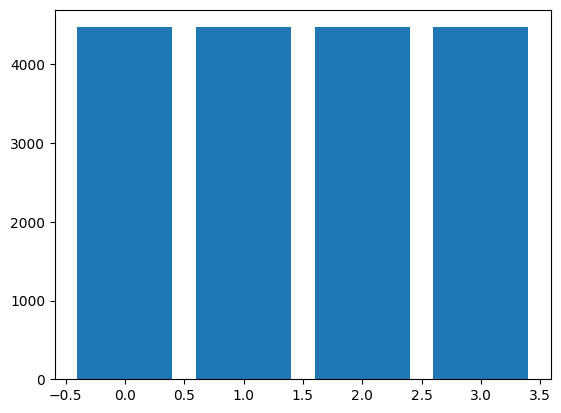

In [19]:
pyplot.bar(counter.keys(), counter.values())  # draw a bar chart for class counts
pyplot.show()  # show the chart

In [20]:
from sklearn.model_selection import train_test_split  # import the train-test split tool
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=101)  # split data into training and testing sets
x_train.head()  # preview the training features
x_train.shape  # check the training data shape

(12513, 18)

In [21]:
x_test.head()  # preview the testing features
x_test.shape  # check the testing data shape

(5363, 18)

In [22]:
# logistic regression
from sklearn.linear_model import LogisticRegression  # import logistic regression
Lr = LogisticRegression()  # create the model
Lr.fit(x_train, y_train)  # train the model on the training data

# Generate predictions for both test and training data
predictions = Lr.predict(x_test)  # predict labels for the test set
train_predictions = Lr.predict(x_train)  # predict labels for the training set

from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools

# Train performance
print("=== Training Performance ===")  # print training results heading
print(classification_report(y_train, train_predictions, digits=4))  # show training metrics
print(confusion_matrix(y_train, train_predictions))  # show training confusion matrix
# test performance
print("=== Test Performance ===")  # print test results heading
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = Lr.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities for ROC work

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # measure agreement between true and predicted labels

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(Lr, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

=== Training Performance ===
              precision    recall  f1-score   support

           0     0.4478    0.6042    0.5144      3120
           1     0.3140    0.1950    0.2406      3113
           2     0.3438    0.2105    0.2611      3112
           3     0.4494    0.6335    0.5258      3168

    accuracy                         0.4119     12513
   macro avg     0.3888    0.4108    0.3855     12513
weighted avg     0.3891    0.4119    0.3862     12513

[[1885  544  297  394]
 [1226  607  525  755]
 [ 671  476  655 1310]
 [ 427  306  428 2007]]
=== Test Performance ===
              precision    recall  f1-score   support

           0     0.4528    0.6116    0.5203      1349
           1     0.3377    0.2087    0.2580      1356
           2     0.3325    0.2063    0.2547      1357
           3     0.4385    0.6272    0.5161      1301

    accuracy                         0.4110      5363
   macro avg     0.3904    0.4135    0.3873      5363
weighted avg     0.3898    0.4110    0

In [23]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier  # import decision tree model
dtree = DecisionTreeClassifier()  # create the model
dtree.fit(x_train, y_train)  # train the model
predictions = dtree.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = dtree.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(dtree, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6734    0.6894    0.6813      1349
           1     0.5117    0.4830    0.4970      1356
           2     0.4376    0.4237    0.4306      1357
           3     0.6635    0.7079    0.6850      1301

    accuracy                         0.5745      5363
   macro avg     0.5716    0.5760    0.5735      5363
weighted avg     0.5705    0.5745    0.5722      5363

[[930 149 157 113]
 [172 655 403 126]
 [187 367 575 228]
 [ 92 109 179 921]]
Cross Validation Scores are [0.59451902 0.60961969 0.58780761 0.62136465 0.62360179 0.61800895
 0.61108002 0.60828204 0.59429211 0.58701735 0.59060403 0.62304251
 0.62583893 0.5950783  0.60682327 0.60290828 0.62506995 0.58813654
 0.62115277 0.5775042  0.59451902 0.60346756 0.60011186 0.62583893
 0.60794183 0.6057047  0.61108002 0.60492445 0.60940123 0.59093453]
Average Cross Validation score :0.6055225368234498


In [24]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier  # import random forest model
rfc = RandomForestClassifier(n_estimators=100)  # create the model with 100 trees
rfc.fit(x_train, y_train)  # train the model
predictions = rfc.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = rfc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(rfc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8747    0.8332    0.8535      1349
           1     0.5901    0.7102    0.6446      1356
           2     0.6439    0.5276    0.5800      1357
           3     0.8381    0.8593    0.8486      1301

    accuracy                         0.7311      5363
   macro avg     0.7367    0.7326    0.7317      5363
weighted avg     0.7354    0.7311    0.7303      5363

[[1124  156   34   35]
 [  49  963  297   47]
 [  77  430  716  134]
 [  35   83   65 1118]]
Cross Validation Scores are [0.74161074 0.76789709 0.76733781 0.74384787 0.75       0.74217002
 0.75209849 0.76329043 0.74202574 0.75097929 0.74552573 0.7533557
 0.75       0.74328859 0.76006711 0.75503356 0.73754896 0.75265809
 0.77168439 0.74370453 0.7360179  0.75503356 0.74832215 0.75111857
 0.74496644 0.7393736  0.73978735 0.76105204 0.76161164 0.75377728]
Average Cross Validation score :0.750839489527272


In [25]:
# K- nearest neighbor
from sklearn.neighbors import KNeighborsClassifier  # import KNN model
KN = KNeighborsClassifier()  # create the model
KN.fit(x_train, y_train)  # train the model
predictions = KN.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = KN.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(KN, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.6648    0.9540    0.7836      1349
           1     0.5825    0.2552    0.3549      1356
           2     0.6542    0.5298    0.5855      1357
           3     0.7203    0.9600    0.8231      1301

    accuracy                         0.6715      5363
   macro avg     0.6554    0.6748    0.6368      5363
weighted avg     0.6548    0.6715    0.6346      5363

[[1287   22   27   13]
 [ 436  346  327  247]
 [ 202  211  719  225]
 [  11   15   26 1249]]
Cross Validation Scores are [0.70246085 0.71420582 0.71364653 0.70637584 0.70805369 0.70637584
 0.70397314 0.71404589 0.72076105 0.71684387 0.70581655 0.72427293
 0.69630872 0.71252796 0.72035794 0.70749441 0.70956911 0.70956911
 0.72691662 0.69110241 0.70357942 0.72147651 0.71252796 0.71588367
 0.68791946 0.71196868 0.70900951 0.71012871 0.71012871 0.70061556]
Average Cross Validation score :0.7097972159523143


In [26]:
# GaussianNB
from sklearn.naive_bayes import GaussianNB  # import Gaussian Naive Bayes model
NB = GaussianNB()  # create the model
NB.fit(x_train, y_train)  # train the model
predictions = NB.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = NB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(NB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4308    0.6464    0.5170      1349
           1     0.3731    0.2028    0.2628      1356
           2     0.3301    0.1746    0.2284      1357
           3     0.4475    0.6480    0.5294      1301

    accuracy                         0.4153      5363
   macro avg     0.3954    0.4180    0.3844      5363
weighted avg     0.3948    0.4153    0.3827      5363

[[872 190 117 170]
 [570 275 230 281]
 [362 168 237 590]
 [220 104 134 843]]
Cross Validation Scores are [0.41275168 0.43400447 0.41331096 0.41163311 0.42897092 0.43400447
 0.42585339 0.41578064 0.39619474 0.423615   0.43008949 0.42170022
 0.42729306 0.40100671 0.41834452 0.41107383 0.43368774 0.41410185
 0.41130386 0.41298265 0.42841163 0.42841163 0.41219239 0.43680089
 0.42114094 0.39932886 0.40626749 0.42081701 0.43648573 0.4040291 ]
Average Cross Validation score :0.4190529664279303


In [27]:
# support vector machine
from sklearn.svm import LinearSVC  # import linear SVM model
classifier = LinearSVC()  # create the model
classifier.fit(x_train, y_train)  # train the model
y_predict = classifier.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_predict, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_predict))  # show test confusion matrix
y_score = classifier.fit(x_train, y_train).decision_function(x_test)  # get decision scores

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, y_predict)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(classifier, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.4245    0.6894    0.5254      1349
           1     0.3551    0.1165    0.1755      1356
           2     0.3178    0.1260    0.1805      1357
           3     0.4107    0.6910    0.5152      1301

    accuracy                         0.4024      5363
   macro avg     0.3770    0.4057    0.3491      5363
weighted avg     0.3766    0.4024    0.3472      5363

[[930 120 100 199]
 [639 158 161 398]
 [386 107 171 693]
 [236  60 106 899]]
Cross Validation Scores are [0.40436242 0.42058166 0.39373602 0.40715884 0.41610738 0.42281879
 0.41074426 0.4029099  0.37940683 0.41186346 0.39317673 0.40995526
 0.42058166 0.40100671 0.40436242 0.39653244 0.41969782 0.39563514
 0.40682708 0.41354225 0.41498881 0.42337808 0.39205817 0.42841163
 0.41498881 0.37583893 0.39171796 0.40906547 0.41578064 0.39171796]
Average Cross Validation score :0.40629845094678735


In [28]:
# AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier  # import AdaBoost model
abc = AdaBoostClassifier(n_estimators=50, learning_rate=1)  # create the model
model = abc.fit(x_train, y_train)  # train the model
y_pred = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, y_pred, digits=4))  # show test metrics
print(confusion_matrix(y_test, y_pred))  # show test confusion matrix
y_score = abc.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(abc, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.5083    0.6368    0.5653      1349
           1     0.4994    0.3296    0.3972      1356
           2     0.3347    0.3633    0.3484      1357
           3     0.4705    0.4719    0.4712      1301

    accuracy                         0.4499      5363
   macro avg     0.4532    0.4504    0.4455      5363
weighted avg     0.4530    0.4499    0.4451      5363

[[859 173 154 163]
 [348 447 404 157]
 [285 208 493 371]
 [198  67 422 614]]
Cross Validation Scores are [0.44742729 0.4893736  0.47371365 0.47651007 0.45190157 0.4541387
 0.46894236 0.46950196 0.461108   0.45271405 0.46700224 0.45302013
 0.46923937 0.46420582 0.47483221 0.47818792 0.47677672 0.45607163
 0.46614438 0.45942921 0.46308725 0.47762864 0.45246085 0.48545861
 0.48434004 0.44742729 0.46950196 0.47453833 0.47285954 0.45998881]
Average Cross Validation score :0.46658440672901935


In [29]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier  # import gradient boosting model
GB = GradientBoostingClassifier()  # create the model
model = GB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = GB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(GB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.7164    0.6872    0.7015      1349
           1     0.5617    0.7522    0.6431      1356
           2     0.4802    0.2763    0.3508      1357
           3     0.6291    0.7118    0.6679      1301

    accuracy                         0.6056      5363
   macro avg     0.5968    0.6069    0.5908      5363
weighted avg     0.5963    0.6056    0.5898      5363

[[ 927  197   66  159]
 [  63 1020  214   59]
 [ 164  490  375  328]
 [ 140  109  126  926]]
Cross Validation Scores are [0.61241611 0.60738255 0.60626398 0.598434   0.60961969 0.61241611
 0.60884163 0.60324566 0.59485171 0.60492445 0.60514541 0.62080537
 0.58221477 0.59395973 0.5950783  0.62807606 0.60492445 0.60884163
 0.6155568  0.62115277 0.60067114 0.6090604  0.59563758 0.63255034
 0.6090604  0.60850112 0.58198097 0.60380526 0.61275881 0.5970901 ]
Average Cross Validation score :0.6061755774470271


In [30]:
# XGBoost
from numpy import loadtxt  # import loadtxt from NumPy
from xgboost import XGBClassifier  # import XGBoost model
XGB = XGBClassifier()  # create the model
model = XGB.fit(x_train, y_train)  # train the model
predictions = model.predict(x_test)  # predict labels for the test set
from sklearn.metrics import classification_report, confusion_matrix  # import evaluation tools
print(classification_report(y_test, predictions, digits=4))  # show test metrics
print(confusion_matrix(y_test, predictions))  # show test confusion matrix
y_score = XGB.fit(x_train, y_train).predict_proba(x_test)  # get prediction probabilities

from sklearn.metrics import cohen_kappa_score  # import kappa score
cohen_kappa_score(y_test, predictions)  # calculate agreement score

from sklearn.model_selection import RepeatedStratifiedKFold  # import repeated stratified k-fold
from sklearn.model_selection import cross_val_score, KFold  # import cross-validation tools
kf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)  # define the cross-validation plan
scores = cross_val_score(XGB, x, y, cv=kf)  # evaluate the model with cross-validation
print("Cross Validation Scores are {}".format(scores))  # print all cross-validation scores
print("Average Cross Validation score :{}".format(scores.mean()))  # print the average score

              precision    recall  f1-score   support

           0     0.8291    0.7984    0.8134      1349
           1     0.5684    0.7294    0.6389      1356
           2     0.5930    0.4466    0.5095      1357
           3     0.7942    0.7948    0.7945      1301

    accuracy                         0.6910      5363
   macro avg     0.6962    0.6923    0.6891      5363
weighted avg     0.6950    0.6910    0.6878      5363

[[1077  178   40   54]
 [  64  989  277   26]
 [ 100  463  606  188]
 [  58  110   99 1034]]
Cross Validation Scores are [0.69127517 0.70805369 0.70581655 0.70246085 0.71308725 0.7041387
 0.6922216  0.69613878 0.69725797 0.70453274 0.68624161 0.72483221
 0.67225951 0.69407159 0.69798658 0.70022371 0.70677112 0.70621153
 0.71516508 0.71964186 0.68736018 0.69295302 0.700783   0.71812081
 0.69966443 0.69407159 0.71012871 0.70789032 0.70509233 0.70733072]
Average Cross Validation score :0.7020594403945638


In [31]:
# Bagging
from sklearn.ensemble import BaggingClassifier
BC=BaggingClassifier()
model=BC.fit(x_train, y_train)
predictions = model.predict(x_test)
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,predictions,digits=4))
print(confusion_matrix(y_test,predictions))
y_score = BC.fit(x_train, y_train).predict_proba(x_test)

from sklearn.metrics import cohen_kappa_score
cohen_kappa_score(y_test,predictions)

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import  cross_val_score,KFold
kf = RepeatedStratifiedKFold(n_splits = 10, n_repeats=3, random_state=1)
scores = cross_val_score(BC, x, y, cv = kf)
print("Cross Validation Scores are {}".format(scores))
print("Average Cross Validation score :{}".format(scores.mean()))

              precision    recall  f1-score   support

           0     0.7412    0.7961    0.7677      1349
           1     0.5627    0.6453    0.6012      1356
           2     0.5302    0.4274    0.4733      1357
           3     0.7652    0.7440    0.7545      1301

    accuracy                         0.6521      5363
   macro avg     0.6498    0.6532    0.6492      5363
weighted avg     0.6485    0.6521    0.6479      5363

[[1074  149   63   63]
 [ 121  875  302   58]
 [ 163  438  580  176]
 [  91   93  149  968]]
Cross Validation Scores are [0.68288591 0.6901566  0.68232662 0.67058166 0.67785235 0.700783
 0.67543369 0.66592054 0.65752658 0.67767208 0.67561521 0.68512304
 0.68680089 0.67561521 0.68680089 0.68288591 0.67543369 0.67207611
 0.68326805 0.6547286  0.67281879 0.66498881 0.67337808 0.68288591
 0.67673378 0.67841163 0.66648013 0.69054281 0.69445999 0.66480134]
Average Cross Validation score :0.6774995962638445
